# AI Resume Analyzer — Dataset Exploration

This notebook explores and preprocesses the resume-job matching dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
from datasets import load_dataset

print("Hugging Face Datasets is working!")

Hugging Face Datasets is working!


In [4]:
dataset = load_dataset("med2425/resume-job-fit-merged-v1")

In [5]:
dataset

DatasetDict({
    train: Dataset({
        features: ['resume', 'jd', 'label', 'source', 'resume_domain', 'jd_domain'],
        num_rows: 80017
    })
    test: Dataset({
        features: ['resume', 'jd', 'label', 'source', 'resume_domain', 'jd_domain'],
        num_rows: 13716
    })
})

In [6]:
print(dataset["train"])

Dataset({
    features: ['resume', 'jd', 'label', 'source', 'resume_domain', 'jd_domain'],
    num_rows: 80017
})


In [7]:
print(dataset["train"].column_names)

['resume', 'jd', 'label', 'source', 'resume_domain', 'jd_domain']


In [8]:
example = dataset["train"][0]

print(example)

{'resume': "SummarySelf-motivated accountant  offering a strong work ethic and determination to complete tasks in a timely manner. Accurate and detail-oriented with extensive auditing and finance knowledge.\nHighlightsComplex problem solvingStrong communication skillsExpert in customer relationsPortfolio managementAProficient in Microsoft OfficeMicrosoft Excel expertRisk management expertiseFinancial statement analysisGeneral ledger accounting\nExperienceCurrentto08/2014AccountantApartment Income Reit Corp.–Nashua,NH,Prepare unpaid reports on actual expenses for marketing line of business.Create and maintain pending and process able database.Prepare and setup vendor purchase orders contracts as well as CRX templates.Verify funding and SAP project code against the most recent budget/forecast submission.Key invoices into ePurchase system as well as approve and reconcile invoices.Track invoices from submission to payment on database.Monitor invoice central mailbox that will include invoic

In [9]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

In [10]:
print(train_df.shape)
print(test_df.shape)

(80017, 6)
(13716, 6)


In [11]:
train_df.to_csv(
    "../data/raw/resume_job_train.csv",
    index=False
)

test_df.to_csv(
    "../data/raw/resume_job_test.csv",
    index=False
)

In [12]:
train_df.head()

,resume,jd,label,source,resume_domain,jd_domain
0,SummarySelf-motivated accountant offering a s...,"Our client, a Raleigh-based full-service comme...",Potential Fit,generated_smart,finance,finance
1,Professional ProfileSpecialized knowledge of r...,"""All candidates must be directly contracted by...",No Fit,generated_smart,finance,software
2,"SummaryEngineering Project Manager\nAmbitious,...",Calling all innovators find your future at Fi...,No Fit,generated_smart,software,software
3,SummaryData Protection Consultant with 10 year...,"MUST WORK ON A W2 INDEPENDENTLY, NO SPONSORSHI...",No Fit,generated_smart,software,data
4,Career OverviewHighly skilled SOFTWARE QUALITY...,Calling all data nerds who love finance! \nIf ...,No Fit,generated_smart,software,data


In [13]:
train_df.shape

(80017, 6)

In [14]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80017 entries, 0 to 80016
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   resume         80017 non-null  str  
 1   jd             80017 non-null  str  
 2   label          80017 non-null  str  
 3   source         80017 non-null  str  
 4   resume_domain  80017 non-null  str  
 5   jd_domain      80017 non-null  str  
dtypes: str(6)
memory usage: 668.9 MB


In [15]:
train_df["label"].value_counts()

label
No Fit           60313
Potential Fit    13907
Good Fit          5797
Name: count, dtype: int64

In [16]:
train_df["resume_domain"].value_counts()

resume_domain
software       37216
data           16662
finance        16059
engineering     4295
management      2739
sales            875
ai               766
healthcare       500
design           289
legal            276
hr               239
marketing        101
Name: count, dtype: int64

In [17]:
train_df["jd_domain"].value_counts()

jd_domain
software       38906
finance        19249
data           16174
management      1796
engineering     1066
ai               705
hr               690
design           522
legal            434
sales            295
healthcare       180
Name: count, dtype: int64

In [18]:
train_df["jd_domain"].value_counts()

jd_domain
software       38906
finance        19249
data           16174
management      1796
engineering     1066
ai               705
hr               690
design           522
legal            434
sales            295
healthcare       180
Name: count, dtype: int64

In [19]:
train_df.isnull().sum()

resume           0
jd               0
label            0
source           0
resume_domain    0
jd_domain        0
dtype: int64

In [20]:
test_df.isnull().sum()

resume           0
jd               0
label            0
source           0
resume_domain    0
jd_domain        0
dtype: int64

In [21]:
train_df.duplicated().sum()

np.int64(0)

In [22]:
test_df.duplicated().sum()

np.int64(0)

In [23]:
train_df["label"].value_counts()

label
No Fit           60313
Potential Fit    13907
Good Fit          5797
Name: count, dtype: int64

In [24]:
train_df["label"].value_counts(normalize=True) * 100

label
No Fit           75.375233
Potential Fit    17.380057
Good Fit          7.244710
Name: proportion, dtype: float64

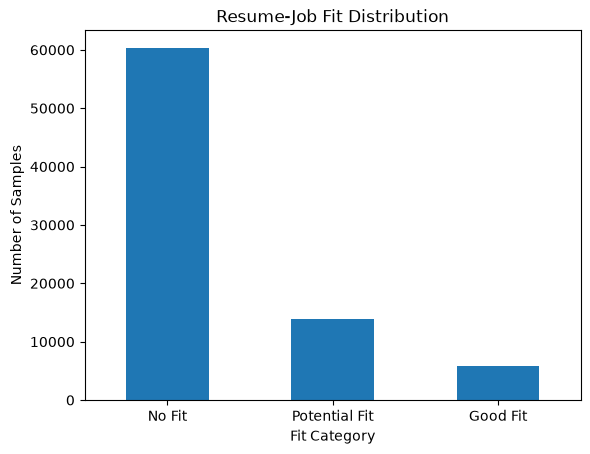

In [25]:
import matplotlib.pyplot as plt

train_df["label"].value_counts().plot(kind="bar")

plt.title("Resume-Job Fit Distribution")
plt.xlabel("Fit Category")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

In [26]:
train_df["resume_length"] = train_df["resume"].str.len()

In [27]:
train_df["resume_length"].describe()

count    80017.000000
mean      5991.573803
std       2889.209411
min        897.000000
25%       4532.000000
50%       5366.000000
75%       6748.000000
max      25364.000000
Name: resume_length, dtype: float64

In [28]:
train_df["jd_length"] = train_df["jd"].str.len()

In [29]:
train_df["jd_length"].describe()

count    80017.000000
mean      2678.568529
std       1619.040993
min         72.000000
25%       1344.000000
50%       2404.000000
75%       3808.000000
max       7669.000000
Name: jd_length, dtype: float64

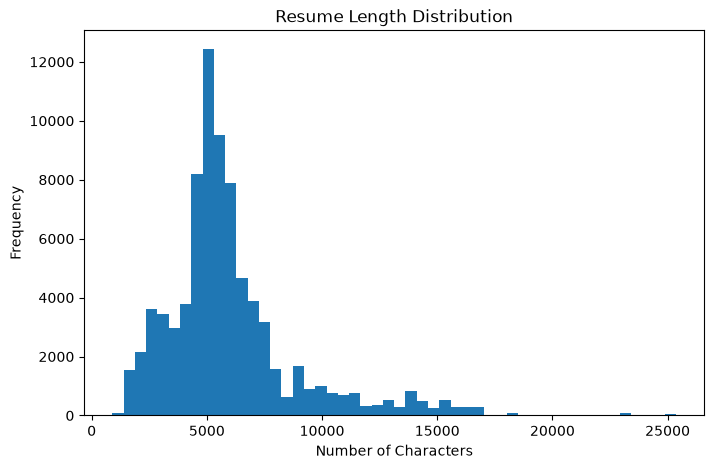

In [30]:
plt.figure(figsize=(8,5))

plt.hist(train_df["resume_length"], bins=50)

plt.title("Resume Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

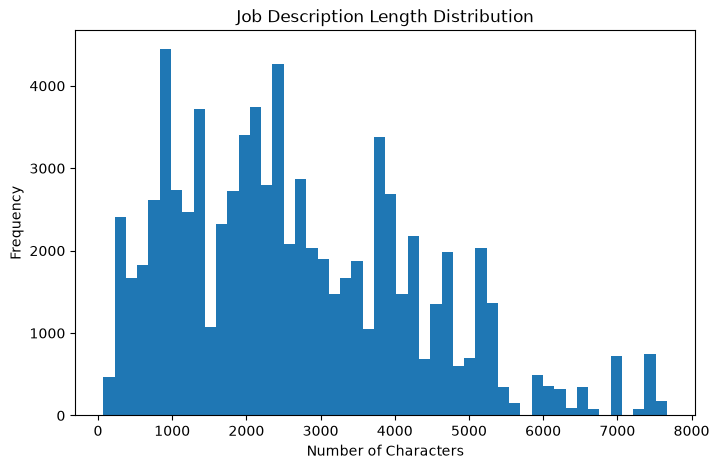

In [31]:
plt.figure(figsize=(8,5))

plt.hist(train_df["jd_length"], bins=50)

plt.title("Job Description Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

# Data Cleaning and NLP Preprocessing

In [32]:
import pandas as pd
import re

In [33]:
train_df = pd.read_csv("../data/raw/resume_job_train.csv")
test_df = pd.read_csv("../data/raw/resume_job_test.csv")

In [34]:
print(train_df.shape)
print(test_df.shape)

(80017, 6)
(13716, 6)


In [35]:
print("Training missing values:")
print(train_df.isnull().sum())

print("\nTest missing values:")
print(test_df.isnull().sum())

Training missing values:
resume           0
jd               0
label            0
source           0
resume_domain    0
jd_domain        0
dtype: int64

Test missing values:
resume           0
jd               0
label            0
source           0
resume_domain    0
jd_domain        0
dtype: int64


In [36]:
train_df = train_df.dropna(subset=["resume", "jd", "label"])
test_df = test_df.dropna(subset=["resume", "jd", "label"])

In [37]:
print(train_df.shape)
print(test_df.shape)

(80017, 6)
(13716, 6)


In [38]:
print("Training duplicates:", train_df.duplicated().sum())
print("Test duplicates:", test_df.duplicated().sum())

Training duplicates: 0
Test duplicates: 0


In [39]:
train_df = train_df.drop_duplicates()
test_df = test_df.drop_duplicates()

In [40]:
print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)

Training shape: (80017, 6)
Test shape: (13716, 6)


In [41]:
def clean_text(text):
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)

    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [42]:
sample = train_df["resume"].iloc[0]

print("BEFORE:")
print(sample)

print("\nAFTER:")
print(clean_text(sample))

BEFORE:
SummarySelf-motivated accountant  offering a strong work ethic and determination to complete tasks in a timely manner. Accurate and detail-oriented with extensive auditing and finance knowledge.
HighlightsComplex problem solvingStrong communication skillsExpert in customer relationsPortfolio managementAProficient in Microsoft OfficeMicrosoft Excel expertRisk management expertiseFinancial statement analysisGeneral ledger accounting
ExperienceCurrentto08/2014AccountantApartment Income Reit Corp.–Nashua,NH,Prepare unpaid reports on actual expenses for marketing line of business.Create and maintain pending and process able database.Prepare and setup vendor purchase orders contracts as well as CRX templates.Verify funding and SAP project code against the most recent budget/forecast submission.Key invoices into ePurchase system as well as approve and reconcile invoices.Track invoices from submission to payment on database.Monitor invoice central mailbox that will include invoice subm

In [43]:
sample_jd = train_df["jd"].iloc[0]

print("BEFORE:")
print(sample_jd)

print("\nAFTER:")
print(clean_text(sample_jd))

BEFORE:
Our client, a Raleigh-based full-service commercial real estate partner, is actively recruiting for a very sharp Property Accountant to join its team to join its growing finance team. 
The company is experiencing exponential growth. The right candidate will have substantial experience in commercial property management and be fully prepared to hit the ground running. This is an excellent opportunity for candidates seeking growth and development. The future is very bright.
This property accountant will be responsible for the financial reporting of Commercial Property, including retail, offices, apartments, and investments. A keen eye for detail will be essential. 
Key Things to Note:Position will frequently interact with management, colleagues, clients, and tenants. Seek a candidate whose financial capabilities complement superb communication and relationship-building skills.Strong Excel and experience with Yardi are a must. This hybrid role requires a few days per week onsite at

In [44]:
train_df["resume_clean"] = train_df["resume"].apply(clean_text)
train_df["jd_clean"] = train_df["jd"].apply(clean_text)

In [45]:
test_df["resume_clean"] = test_df["resume"].apply(clean_text)
test_df["jd_clean"] = test_df["jd"].apply(clean_text)

In [46]:
print("ORIGINAL:")
print(train_df["resume"].iloc[0])

print("\nCLEANED:")
print(train_df["resume_clean"].iloc[0])

ORIGINAL:
SummarySelf-motivated accountant  offering a strong work ethic and determination to complete tasks in a timely manner. Accurate and detail-oriented with extensive auditing and finance knowledge.
HighlightsComplex problem solvingStrong communication skillsExpert in customer relationsPortfolio managementAProficient in Microsoft OfficeMicrosoft Excel expertRisk management expertiseFinancial statement analysisGeneral ledger accounting
ExperienceCurrentto08/2014AccountantApartment Income Reit Corp.–Nashua,NH,Prepare unpaid reports on actual expenses for marketing line of business.Create and maintain pending and process able database.Prepare and setup vendor purchase orders contracts as well as CRX templates.Verify funding and SAP project code against the most recent budget/forecast submission.Key invoices into ePurchase system as well as approve and reconcile invoices.Track invoices from submission to payment on database.Monitor invoice central mailbox that will include invoice su

In [47]:
print("ORIGINAL:")
print(train_df["jd"].iloc[0])

print("\nCLEANED:")
print(train_df["jd_clean"].iloc[0])

ORIGINAL:
Our client, a Raleigh-based full-service commercial real estate partner, is actively recruiting for a very sharp Property Accountant to join its team to join its growing finance team. 
The company is experiencing exponential growth. The right candidate will have substantial experience in commercial property management and be fully prepared to hit the ground running. This is an excellent opportunity for candidates seeking growth and development. The future is very bright.
This property accountant will be responsible for the financial reporting of Commercial Property, including retail, offices, apartments, and investments. A keen eye for detail will be essential. 
Key Things to Note:Position will frequently interact with management, colleagues, clients, and tenants. Seek a candidate whose financial capabilities complement superb communication and relationship-building skills.Strong Excel and experience with Yardi are a must. This hybrid role requires a few days per week onsite 

In [48]:
print("Empty resumes:",
      (train_df["resume_clean"].str.len() == 0).sum())

print("Empty job descriptions:",
      (train_df["jd_clean"].str.len() == 0).sum())

Empty resumes: 0
Empty job descriptions: 0


In [49]:
print("Empty test resumes:",
      (test_df["resume_clean"].str.len() == 0).sum())

print("Empty test job descriptions:",
      (test_df["jd_clean"].str.len() == 0).sum())

Empty test resumes: 0
Empty test job descriptions: 0


In [50]:
train_df = train_df[
    (train_df["resume_clean"].str.len() > 0) &
    (train_df["jd_clean"].str.len() > 0)
]

test_df = test_df[
    (test_df["resume_clean"].str.len() > 0) &
    (test_df["jd_clean"].str.len() > 0)
]

In [51]:
sample = train_df["resume_clean"].iloc[0]

tokens = sample.split()

print(tokens)

['summaryself', 'motivated', 'accountant', 'offering', 'a', 'strong', 'work', 'ethic', 'and', 'determination', 'to', 'complete', 'tasks', 'in', 'a', 'timely', 'manner', 'accurate', 'and', 'detail', 'oriented', 'with', 'extensive', 'auditing', 'and', 'finance', 'knowledge', 'highlightscomplex', 'problem', 'solvingstrong', 'communication', 'skillsexpert', 'in', 'customer', 'relationsportfolio', 'managementaproficient', 'in', 'microsoft', 'officemicrosoft', 'excel', 'expertrisk', 'management', 'expertisefinancial', 'statement', 'analysisgeneral', 'ledger', 'accounting', 'experiencecurrentto', 'accountantapartment', 'income', 'reit', 'corp', 'nashua', 'nh', 'prepare', 'unpaid', 'reports', 'on', 'actual', 'expenses', 'for', 'marketing', 'line', 'of', 'business', 'create', 'and', 'maintain', 'pending', 'and', 'process', 'able', 'database', 'prepare', 'and', 'setup', 'vendor', 'purchase', 'orders', 'contracts', 'as', 'well', 'as', 'crx', 'templates', 'verify', 'funding', 'and', 'sap', 'projec

In [52]:
train_df.to_csv(
    "../data/processed/train_cleaned.csv",
    index=False
)

test_df.to_csv(
    "../data/processed/test_cleaned.csv",
    index=False
)